In [6]:
import pandas as pd
import numpy as np

df = pd.read_csv('../data/YRBS_2007.csv')

cleaned_df = df[['RaceEth', 'HowTallAreYouWithoutShoesInMeters']].dropna()

print("--- 前 10 筆資料預覽 ---")
print(cleaned_df.head(10))

print("\n--- 身高基本統計描述 ---")
print(cleaned_df['HowTallAreYouWithoutShoesInMeters'].describe())

--- 前 10 筆資料預覽 ---
    RaceEth  HowTallAreYouWithoutShoesInMeters
1       5.0                               1.70
3       7.0                               1.63
5       7.0                               1.73
6       5.0                               1.78
7       5.0                               1.60
8       5.0                               1.57
9       5.0                               1.60
10      5.0                               1.57
11      5.0                               1.73
12      5.0                               1.60

--- 身高基本統計描述 ---
count    12885.000000
mean         1.693866
std          0.101329
min          1.270000
25%          1.630000
50%          1.680000
75%          1.780000
max          2.110000
Name: HowTallAreYouWithoutShoesInMeters, dtype: float64


In [7]:
print("--- 各種族/族群的學生人數 ---")
print(cleaned_df['RaceEth'].value_counts())

--- 各種族/族群的學生人數 ---
RaceEth
5.0    5483
3.0    2748
6.0    1824
7.0    1711
2.0     395
8.0     355
1.0     275
4.0      94
Name: count, dtype: int64


C:\Users\User\AppData\Local\Temp\ipykernel_13208\2211518170.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='RaceEth', y='HowTallAreYouWithoutShoesInMeters', data=cleaned_df, palette='Set2')


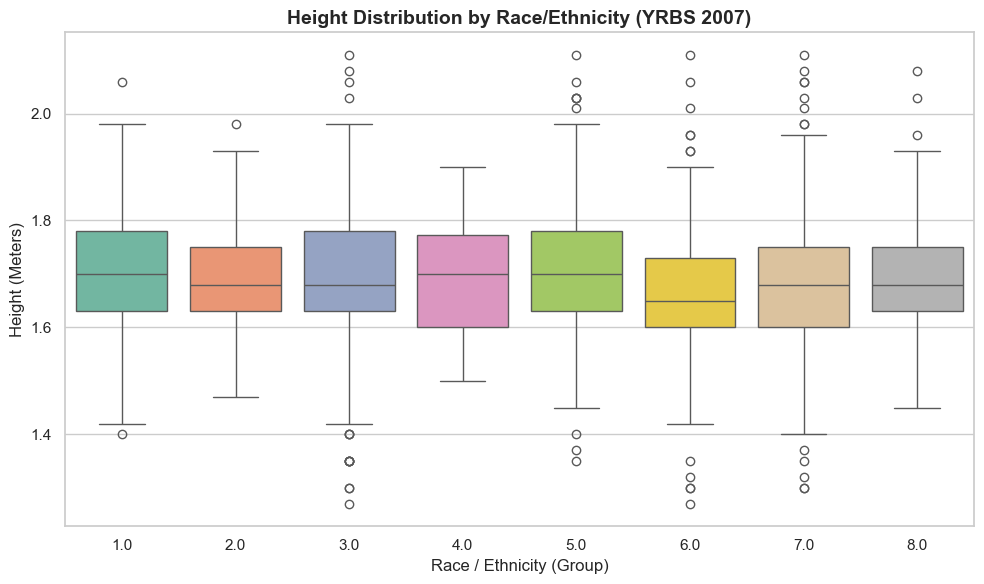

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 6))

sns.boxplot(x='RaceEth', y='HowTallAreYouWithoutShoesInMeters', data=cleaned_df, palette='Set2')

plt.title('Height Distribution by Race/Ethnicity (YRBS 2007)', fontsize=14, fontweight='bold')
plt.xlabel('Race / Ethnicity (Group)', fontsize=12)
plt.ylabel('Height (Meters)', fontsize=12)

plt.tight_layout()
plt.show()

In [9]:
import scipy.stats as stats
from statsmodels.stats.multicomp import pairwise_tukeyhsd

# 1. 將不同種族的身高數據分組（打包成一個 list）
groups = [group['HowTallAreYouWithoutShoesInMeters'].values for name, group in cleaned_df.groupby('RaceEth')]

# 2. 跑 One-way ANOVA 檢定
f_stat, p_val = stats.f_oneway(*groups)
print("=== One-way ANOVA 結果 ===")
print(f"F 檢定值 (F-statistic): {f_stat:.4f}")
print(f"P 值 (p-value): {p_val}")

print("\n=======================================================\n")

# 3. 如果 P 值小於 0.05（顯著），自動跑 Tukey's HSD 事後兩兩比較
if p_val < 0.05:
    print("【結論預覽】: P < 0.05，代表不同種族之間的身高有顯著差異！")
    print("正在計算 Tukey's HSD 事後比較，看看究竟是哪兩組之間有差...\n")
    
    tukey = pairwise_tukeyhsd(endog=cleaned_df['HowTallAreYouWithoutShoesInMeters'],
                              groups=cleaned_df['RaceEth'],
                              alpha=0.05)
    print(tukey)
else:
    print("【結論預覽】: P >= 0.05，代表不同種族之間的身高沒有達到顯著差異。")

=== One-way ANOVA 結果 ===
F 檢定值 (F-statistic): 44.9176
P 值 (p-value): 3.1245005500968403e-63


【結論預覽】: P < 0.05，代表不同種族之間的身高有顯著差異！
正在計算 Tukey's HSD 事後比較，看看究竟是哪兩組之間有差...

Multiple Comparison of Means - Tukey HSD, FWER=0.05 
group1 group2 meandiff p-adj   lower   upper  reject
----------------------------------------------------
   1.0    2.0  -0.0248 0.0351 -0.0486 -0.0009   True
   1.0    3.0  -0.0119 0.5639 -0.0311  0.0073  False
   1.0    4.0  -0.0107 0.9866  -0.047  0.0256  False
   1.0    5.0   -0.001    1.0 -0.0198  0.0177  False
   1.0    6.0   -0.045    0.0 -0.0646 -0.0254   True
   1.0    7.0  -0.0284 0.0003 -0.0482 -0.0087   True
   1.0    8.0  -0.0195 0.2269 -0.0439  0.0048  False
   2.0    3.0   0.0129 0.2485 -0.0035  0.0292  False
   2.0    4.0   0.0141 0.9251 -0.0208  0.0489  False
   2.0    5.0   0.0237 0.0001  0.0079  0.0396   True
   2.0    6.0  -0.0202 0.0066 -0.0371 -0.0034   True
   2.0    7.0  -0.0037 0.9981 -0.0206  0.0133  False
   2.0    8.0   0.0052 0.9966  -0.017